# Regression: Exercise

This exercise covers the development of the first linear regression model using the **Boston Housing Dataset**. The dataset is `datasets/housing.csv`.

The dataset contains the following variables:

| Column | Description |
|--------|-------------|
| `CRIM` | Per capita crime rate by town |
| `ZN` | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| `INDUS` | Proportion of non-retail business acres per town |
| `CHAS` | Dummy variable indicating proximity to the Charles River |
| `NOX` | Nitric oxide concentration (parts per 10 million) |
| `RM` | Average number of rooms per dwelling |
| `AGE` | Proportion of owner-occupied units built prior to 1940 |
| `DIS` | Weighted distances to five Boston employment centres |
| `RAD` | Index of accessibility to radial highways |
| `TAX` | Full-value property tax rate per $10,000 |
| `PTRATIO` | Pupil-teacher ratio by town |
| `B` | 1000(Bk - 0.63)² where Bk is the proportion of Black residents by town |
| `LSTAT` | Percentage of lower-status population |
| `PRICE` | Median value of owner-occupied homes in $1,000s *(target)* |

**Tasks:**

1. The correlation matrix is computed and visualized
2. A simple linear regression model is trained and evaluated using the variable most correlated with the target
3. A multiple linear regression model is trained and evaluated using the two variables most correlated with the target
4. A third variable is added; several polynomial regression models up to degree 5 are trained and evaluated, both with and without intercept
5. A linear regression model is trained and evaluated using all variables in the dataset
6. The data is normalized and the model is retrained — performance is compared
7. The data is standardized and the model is retrained — performance is compared
8. The full-feature model is used to predict housing prices for the records in `datasets/housing_predict.csv`
9. Results are saved in an Excel file `datasets/housing_estimate.xlsx` with columns `OWNER` and `ESTIMATED PRICE`

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('datasets/housing.csv', index_col=0)
print(f'Shape: {df.shape}')
df.head()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## Step 1 - Correlation matrix

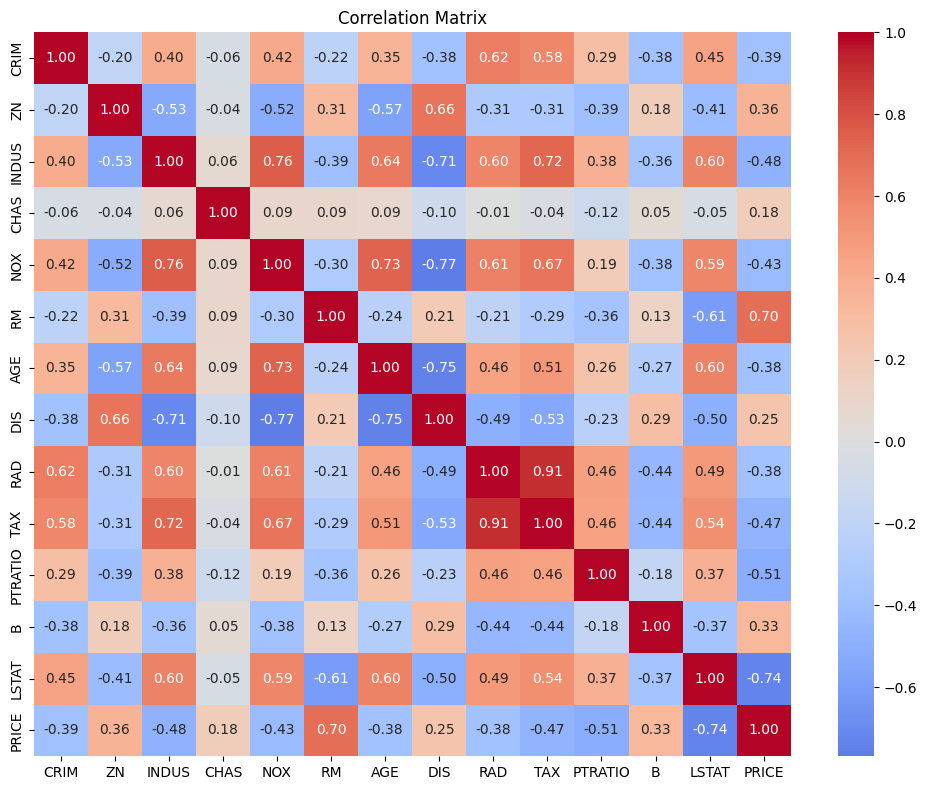

Correlation with PRICE (sorted):
LSTAT     -0.737663
RM         0.695360
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.385832
RAD       -0.381626
AGE       -0.376955
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
Name: PRICE, dtype: float64


In [44]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('Correlation with PRICE (sorted):')
print(corr['PRICE'].drop('PRICE').sort_values(key=abs, ascending=False))

## Step 2 - Simple linear regression (1 variable)

Most correlated feature: LSTAT (r = -0.738)
R²:   0.5429
RMSE: 5.7896


/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature 

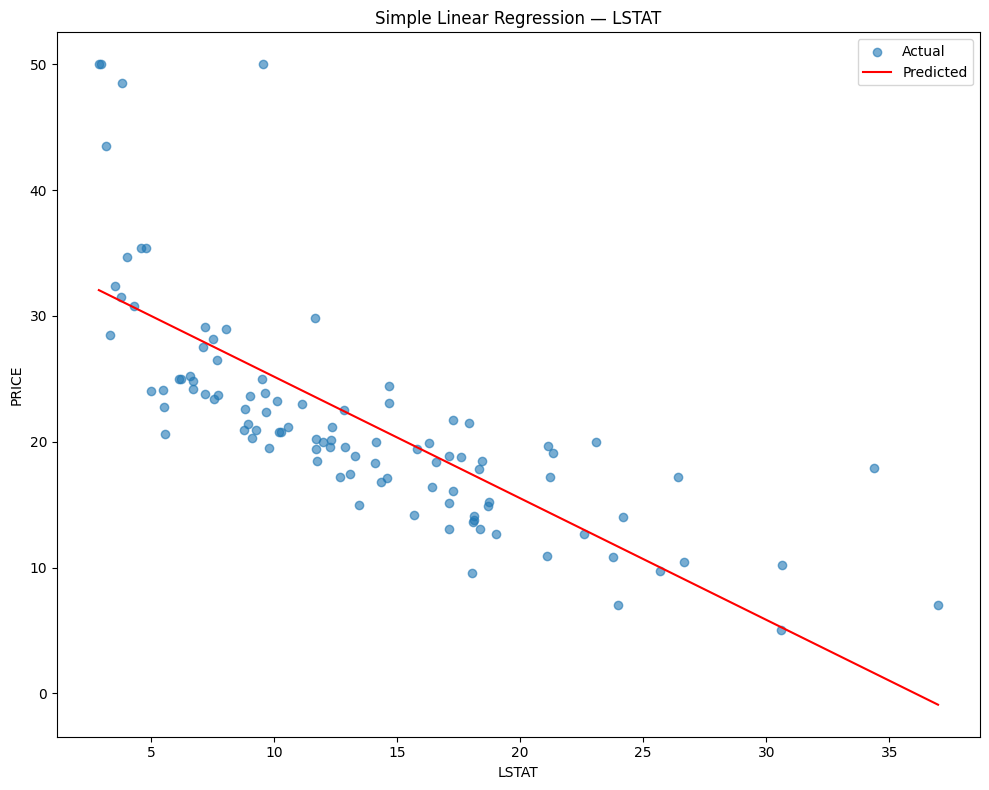

In [45]:
top_features = corr['PRICE'].drop('PRICE').sort_values(key=abs, ascending=False)
feat1 = top_features.index[0]
print(f'Most correlated feature: {feat1} (r = {top_features[feat1]:.3f})')

X = df[[feat1]]
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
y_pred = model_simple.predict(X_test)

r2_simple = r2_score(y_test, y_pred)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'R²:   {r2_simple:.4f}')
print(f'RMSE: {rmse_simple:.4f}')

plt.figure(figsize=(10, 8))
plt.scatter(X_test, y_test, alpha=0.6, label='Actual')
plt.plot(sorted(X_test[feat1]), [model_simple.predict([[v]])[0] for v in sorted(X_test[feat1])], color='red', label='Predicted')
plt.xlabel(feat1)
plt.ylabel('PRICE')
plt.title(f'Simple Linear Regression — {feat1}')
plt.legend()
plt.tight_layout()
plt.show()

## Step 3 - Multiple linear regression (2 variables)

In [46]:
feat2 = top_features.index[1]
print(f'Top 2 features: {feat1}, {feat2}')

X = df[[feat1, feat2]]
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_multi2 = LinearRegression()
model_multi2.fit(X_train, y_train)
y_pred = model_multi2.predict(X_test)

r2_multi2 = r2_score(y_test, y_pred)
rmse_multi2 = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'R²:   {r2_multi2:.4f}')
print(f'RMSE: {rmse_multi2:.4f}')

Top 2 features: LSTAT, RM
R²:   0.5740
RMSE: 5.5896


## Step 4 - Polynomial regression (3 variables, degrees 1–5, with and without intercept)

In [47]:
feat3 = top_features.index[2]
print(f'Top 3 features: {feat1}, {feat2}, {feat3}\n')

X = df[[feat1, feat2, feat3]]
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly_results = []
best_poly = {'r2': -np.inf}

for degree in range(1, 6):
    for with_intercept in [True, False]:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = LinearRegression(fit_intercept=with_intercept)
        model.fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)

        r2 = round(r2_score(y_test, y_pred), 4)
        rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)

        poly_results.append({
            'degree': degree,
            'intercept': with_intercept,
            'R²': r2,
            'RMSE': rmse
        })

        if r2 > best_poly['r2']:
            best_poly = {'r2': r2, 'rmse': rmse, 'degree': degree, 'intercept': with_intercept}

pd.DataFrame(poly_results)

Top 3 features: LSTAT, RM, PTRATIO



,degree,intercept,R²,RMSE
0,1,True,0.6303,5.2072
1,1,False,0.5941,5.4556
2,2,True,0.7779,4.0360
3,2,False,0.7641,4.1593
4,3,True,0.6131,5.3269
5,3,False,0.6564,5.0195
6,4,True,0.5767,5.5714
7,4,False,0.6297,5.2113
8,5,True,0.5663,5.6393
9,5,False,0.5829,5.5303


## Step 5 - Linear regression with all variables

In [48]:
X = df.drop(columns='PRICE')
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_full = LinearRegression()
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)

r2_full = r2_score(y_test, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full))
print(f'All features — R²: {r2_full:.4f} | RMSE: {rmse_full:.4f}')

coef_df = pd.Series(model_full.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print('\nCoefficients:')
print(coef_df)

All features — R²: 0.6685 | RMSE: 4.9307

Coefficients:
NOX       -17.240635
RM          4.432488
CHAS        2.786767
DIS        -1.448485
PTRATIO    -0.916399
LSTAT      -0.509349
RAD         0.262114
CRIM       -0.112463
INDUS       0.040731
ZN          0.030081
B           0.012452
TAX        -0.010639
AGE        -0.006240
dtype: float64


## Step 6 - Normalization (MinMax) and model retraining

In [49]:
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

model_mm = LinearRegression()
model_mm.fit(X_train_mm, y_train)
y_pred_mm = model_mm.predict(X_test_mm)

r2_mm = r2_score(y_test, y_pred_mm)
rmse_mm = np.sqrt(mean_squared_error(y_test, y_pred_mm))
print(f'Normalized (MinMax)   — R²: {r2_mm:.4f} | RMSE: {rmse_mm:.4f}')
print(f'Baseline (no scaling) — R²: {r2_full:.4f} | RMSE: {rmse_full:.4f}')
print()
print('Note: OLS linear regression is invariant to feature scaling.')
print('Scaling changes the coefficient magnitudes but not the predictions or error metrics.')

Normalized (MinMax)   — R²: 0.6685 | RMSE: 4.9307
Baseline (no scaling) — R²: 0.6685 | RMSE: 4.9307

Note: OLS linear regression is invariant to feature scaling.
Scaling changes the coefficient magnitudes but not the predictions or error metrics.


## Step 7 - Standardization (Z-score) and model retraining

In [50]:
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

model_std = LinearRegression()
model_std.fit(X_train_std, y_train)
y_pred_std = model_std.predict(X_test_std)

r2_std = r2_score(y_test, y_pred_std)
rmse_std = np.sqrt(mean_squared_error(y_test, y_pred_std))
print(f'Standardized (Z-score) — R²: {r2_std:.4f} | RMSE: {rmse_std:.4f}')
print(f'Baseline (no scaling)  — R²: {r2_full:.4f} | RMSE: {rmse_full:.4f}')
print()
print('Note: OLS linear regression is invariant to feature scaling.')
print('Scaling changes the coefficient magnitudes but not the predictions or error metrics.')

Standardized (Z-score) — R²: 0.6685 | RMSE: 4.9307
Baseline (no scaling)  — R²: 0.6685 | RMSE: 4.9307

Note: OLS linear regression is invariant to feature scaling.
Scaling changes the coefficient magnitudes but not the predictions or error metrics.


## Step 8 - Predict housing prices from `housing_predict.csv`

In [51]:
df_predict = pd.read_csv('datasets/housing_predict.csv')
owners = df_predict['OWNER']

feature_cols = X.columns.tolist()
X_new = df_predict[feature_cols]

estimated_prices = model_full.predict(X_new)

print('Predictions:')
for owner, price in zip(owners, estimated_prices):
    print(f'  {owner}: ${price:.1f}k')

Predictions:
  Alan Turing: $22.4k
  Elon Musk: $25.5k
  Steve Jobs: $20.4k
  Chuck Norris: $26.5k
  Giuseppe Gullo: $29.4k


## Step 9 - Save results to `housing_estimate.xlsx`

In [52]:
results_df = pd.DataFrame({
    'OWNER': owners.values,
    'ESTIMATED PRICE': estimated_prices.round(2)
})

output_path = 'datasets/housing_estimate.xlsx'
results_df.to_excel(output_path, index=False)
print(f'Saved to {output_path}')
results_df

Saved to datasets/housing_estimate.xlsx


,OWNER,ESTIMATED PRICE
0,Alan Turing,22.45
1,Elon Musk,25.52
2,Steve Jobs,20.40
3,Chuck Norris,26.48
4,Giuseppe Gullo,29.43


## Final Model Comparison

In [53]:
summary = pd.DataFrame([
    {
        'Model': f'Simple LR (1 feature: {feat1})',
        'Features': 1,
        'R²': round(r2_simple, 4),
        'RMSE': round(rmse_simple, 4)
    },
    {
        'Model': f'Multiple LR (2 features: {feat1}, {feat2})',
        'Features': 2,
        'R²': round(r2_multi2, 4),
        'RMSE': round(rmse_multi2, 4)
    },
    {
        'Model': f'Best Polynomial (degree={best_poly["degree"]}, intercept={best_poly["intercept"]}, 3 features)',
        'Features': 3,
        'R²': best_poly['r2'],
        'RMSE': best_poly['rmse']
    },
    {
        'Model': 'Full LR (all features)',
        'Features': X.shape[1],
        'R²': round(r2_full, 4),
        'RMSE': round(rmse_full, 4)
    },
    {
        'Model': 'Full LR + MinMax Normalization',
        'Features': X.shape[1],
        'R²': round(r2_mm, 4),
        'RMSE': round(rmse_mm, 4)
    },
    {
        'Model': 'Full LR + Z-score Standardization',
        'Features': X.shape[1],
        'R²': round(r2_std, 4),
        'RMSE': round(rmse_std, 4)
    },
])

summary = summary.sort_values('R²', ascending=False).reset_index(drop=True)
print('Models ranked by R² (higher is better):')
summary

Models ranked by R² (higher is better):


,Model,Features,R²,RMSE
0,"Best Polynomial (degree=2, intercept=True, 3 f...",3,0.7779,4.0360
1,Full LR (all features),13,0.6685,4.9307
2,Full LR + MinMax Normalization,13,0.6685,4.9307
3,Full LR + Z-score Standardization,13,0.6685,4.9307
4,"Multiple LR (2 features: LSTAT, RM)",2,0.5740,5.5896
5,Simple LR (1 feature: LSTAT),1,0.5429,5.7896


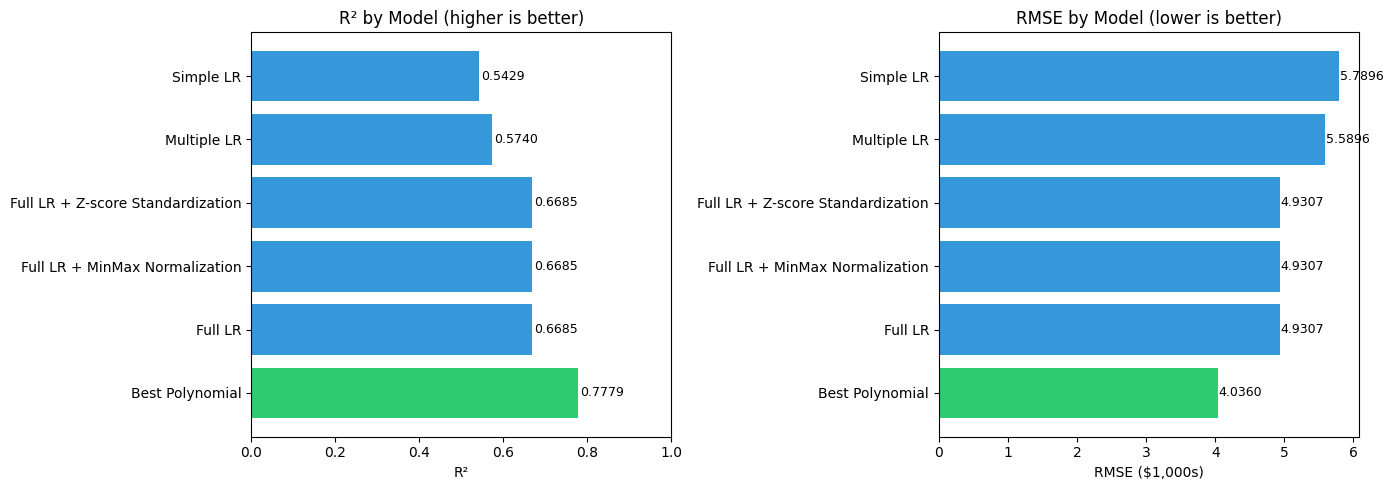

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(summary))]
labels = [m.split('(')[0].strip() for m in summary['Model']]

axes[0].barh(labels, summary['R²'], color=colors)
axes[0].set_xlabel('R²')
axes[0].set_title('R² by Model (higher is better)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(summary['R²']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(labels, summary['RMSE'], color=colors)
axes[1].set_xlabel('RMSE ($1,000s)')
axes[1].set_title('RMSE by Model (lower is better)')
for i, v in enumerate(summary['RMSE']):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()